# Data-mining nearby galaxies

### The following libraries are required
- numpy
- sys
- ToltecSignalFits
- InputModelFits


The % matplotlib command allows the user to interact with the graph. To read the file ToltecSignalFits is used in this case with array= a1100 and weight cut is specified to not use all sources.The edges have a lower weight than the center.

Finally, the plot Image command shows us the graph.

['./Toltec_simu_a1100_filtered.fits']
Fits file found: ./Toltec_simu_a1100_filtered.fits


<IPython.core.display.Javascript object>


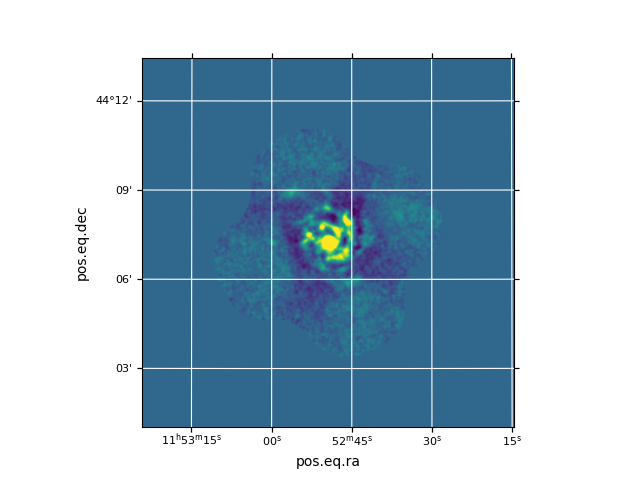

<WCSAxesSubplot:>

In [1]:
%matplotlib notebook 
import numpy as np
import sys
sys.path.append('toltec_pybdsf_scripts-main 3')
from ToltecSignalFits import ToltecSignalFits
from InputModelFits import InputModelFits
reducedpath="./"
tf1p1 = ToltecSignalFits(reducedpath, array='a1100') # To load the file
tf1p1.setWeightCut(0.6) # To use 0.6 weight sources 
tf1p1.plotImage('signal_I',vmin=-0.5 , vmax=1) # shows the image


Then we are going to segment the image from the TolTEC observations, the segmentation is named segm_deblend. To see this segmentation we use a matplotlib plot. 

<QTable length=20>
      name        dtype  unit  class   n_bad
---------------- ------- ---- -------- -----
           label   int64        Column     0
       xcentroid float64        Column     0
       ycentroid float64        Column     0
    sky_centroid  object        Column     0
       bbox_xmin   int64        Column     0
       bbox_xmax   int64        Column     0
       bbox_ymin   int64        Column     0
       bbox_ymax   int64        Column     0
            area float64 pix2 Quantity     0
 semimajor_sigma float64  pix Quantity     0
 semiminor_sigma float64  pix Quantity     0
     orientation float64  deg Quantity     0
    eccentricity float64      Quantity     0
       min_value float64        Column     0
       max_value float64        Column     0
local_background float64        Column     0
    segment_flux float64        Column     0
 segment_fluxerr float64        Column    20
       kron_flux float64        Column     0
    kron_fluxerr float64        Colu

<IPython.core.display.Javascript object>


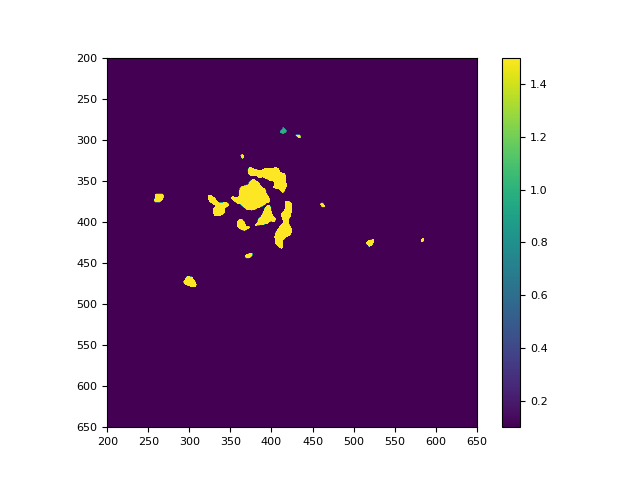

In [2]:
table_phot,segm_deblend=tf1p1.segment() # tf1p1 segmentation
table_phot.info() # information of table_phot
y=segm_deblend.data
import matplotlib.pyplot as plt 
plt.figure() 
plt.xlim(200, 650) # x-axis limits
plt.ylim(650, 200) # y-axis limits
plt.imshow(y,vmin=0.1,vmax=1.5) # shows segm_deblend.data
plt.colorbar()


The next step is to compare the flux, plot the input and output models, and segmentation. To load the file we use **InputModelFits** class, it has a MIPS 24 resolution. This file is the model input so to adjust its resolution to TolTEC resolution we use Gaussian 07 as a follows

func=InputModelFits("file name input model",array, kernel File)

Then, the imagen TolTEC are not the same imagen input so to adjust the pixels we use **reprojectInputToOutput** . This function reproject the pixels of the image input to image output. 
Write this reproject of the image of observations TolTEC with writeReproject and to plot the fitted models we use **plotModObs**.
Finally, we use the inPhot method to table the photometry of segm_deblend using the input model.

/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: divide by zero encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])
/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: invalid value encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])


<IPython.core.display.Javascript object>


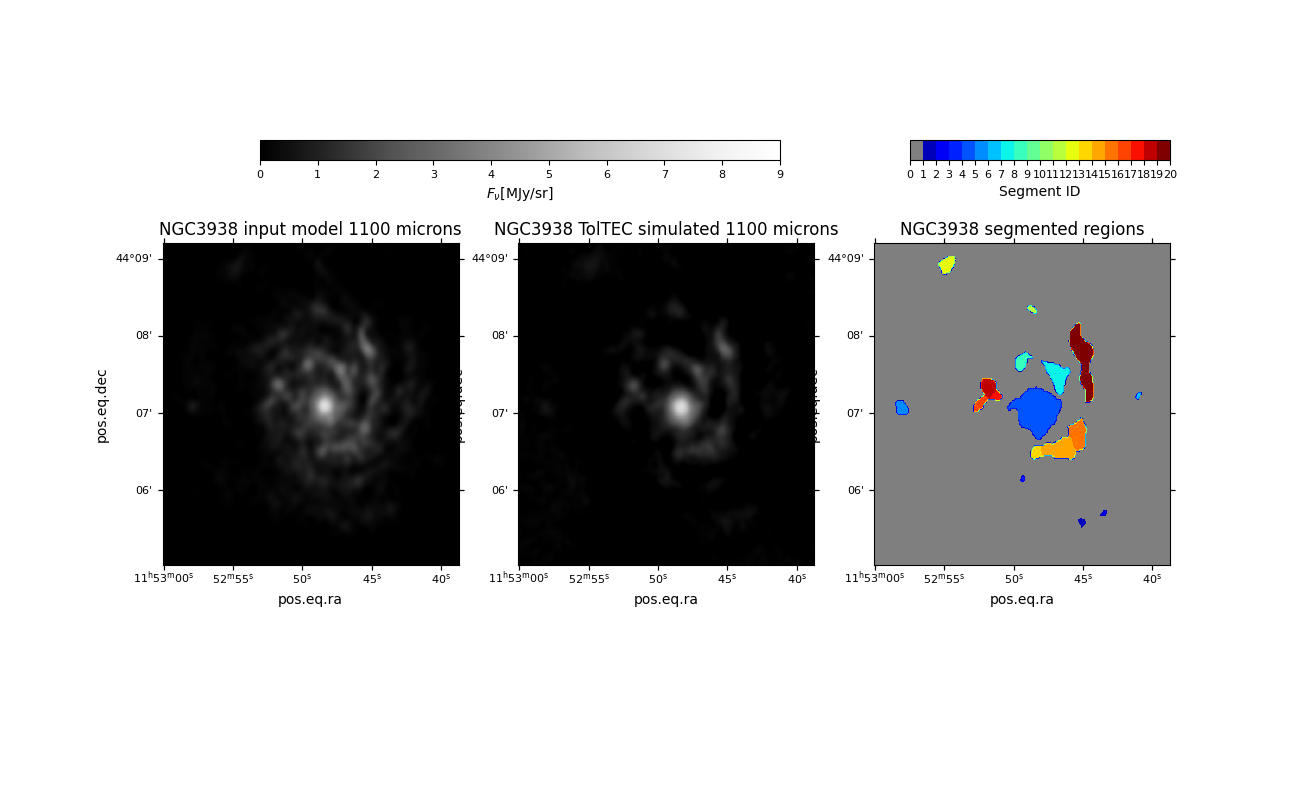

<IPython.core.display.Javascript object>


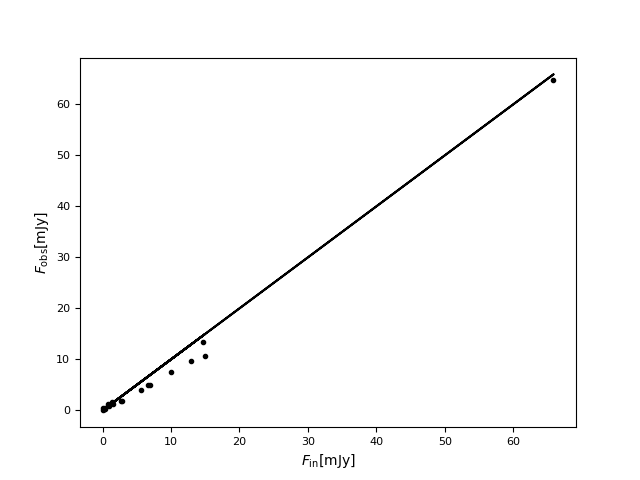

In [3]:
# To adjust resolution the image 
inputmodel=InputModelFits(filename="/Users/mariajosemejiamorales/Desktop/praticas/ngc3938_11mm_eqCalz_MJypersr_pixsize1.fits",array= "a1100",kernelFile="Kernel_LowRes_MIPS_24_to_Gauss_07.0.fits.gz")
# To adjust pixels
repromodel=inputmodel.reprojectInputToOutput(tf1p1) 

inputmodel.writeReproject(tf1p1)

inputmodel.plotModObs(tf1p1,segm_deblend,extent=(260,490,240,490)) # shows input model, out model and segmentation

tbl_input=inputmodel.inPhot(segm_deblend)# photometry 


inputmodel.plotExtPhot(table_phot) # To show the graph of comparasion fluxes 


Now we use the same procedure for array=1400 and 2000. 

['./Toltec_simu_a1400_filtered.fits']
Fits file found: ./Toltec_simu_a1400_filtered.fits


<IPython.core.display.Javascript object>


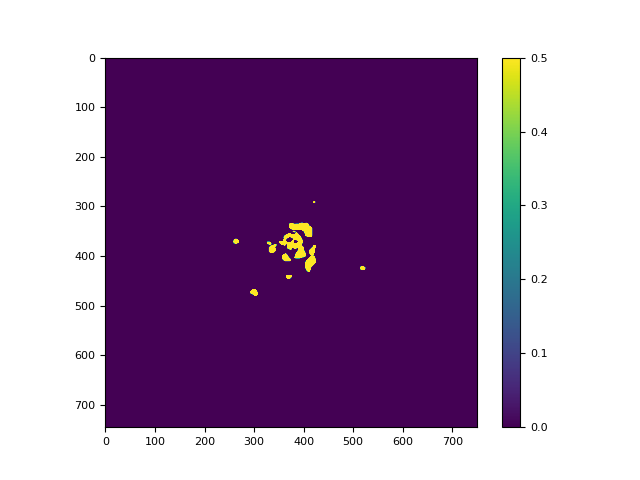

/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: divide by zero encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])
/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: invalid value encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])


<IPython.core.display.Javascript object>


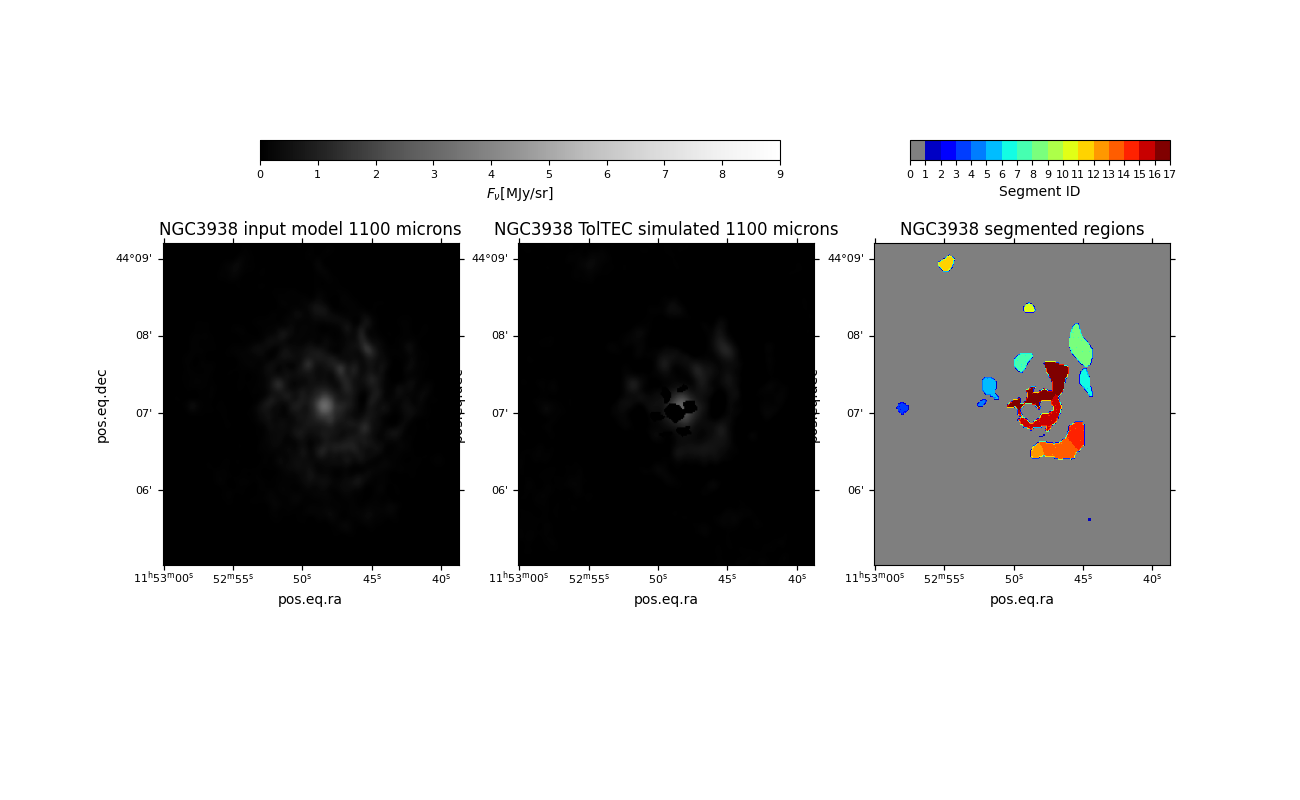

<IPython.core.display.Javascript object>


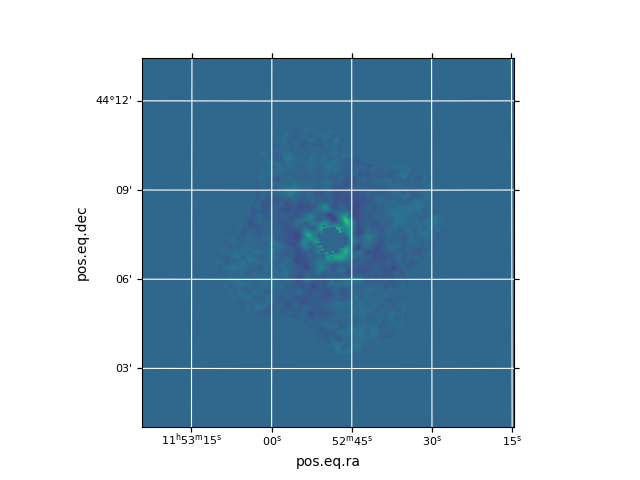

In [4]:
reducedpath2="./"
tf1p2 = ToltecSignalFits(reducedpath2, array='a1400')
tf1p2.setWeightCut(0.6)
tf1p2.plotImage('signal_I',vmin=-0.5 , vmax=1)
table_phot2,segm_deblend2=tf1p2.segment()
y2=segm_deblend2
import matplotlib.pyplot as plt
plt.figure() 
plt.imshow(y2,vmin=0,vmax=0.5) 
plt.colorbar()
inputmodel2=InputModelFits(filename="/Users/mariajosemejiamorales/Desktop/praticas/ngc3938_11mm_eqCalz_MJypersr_pixsize1.fits",array= "a1400",kernelFile="Kernel_LowRes_MIPS_24_to_Gauss_07.0.fits.gz")

repromodel2=inputmodel2.reprojectInputToOutput(tf1p2)

inputmodel2.writeReproject(tf1p2)

inputmodel2.plotModObs(tf1p2,segm_deblend2,extent=(260,490,240,490))

tbl_input2=inputmodel2.inPhot(segm_deblend2)



inputmodel2.plotExtPhot(table_phot2)


['./Toltec_simu_a2000_filtered.fits']
Fits file found: ./Toltec_simu_a2000_filtered.fits


/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: divide by zero encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])
/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main 3/InputModelFits.py:71: RuntimeWarning: invalid value encountered in divide
  hdu_ratio=fits.PrimaryHDU(hdurepro.data*flux_fact/(toltec_signal_out.getMap('signal_I')*flux_fact),header=toltec_signal_out.headers[1])


<IPython.core.display.Javascript object>


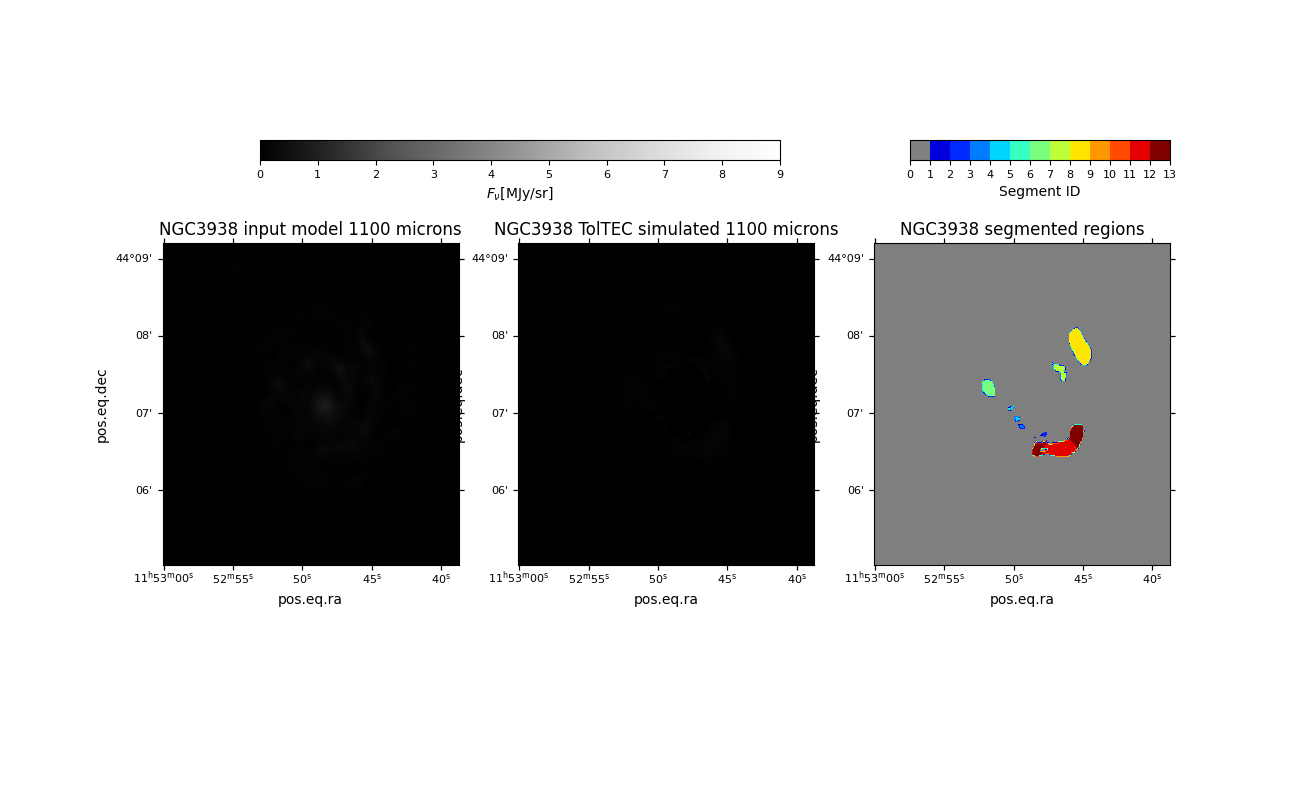

<IPython.core.display.Javascript object>


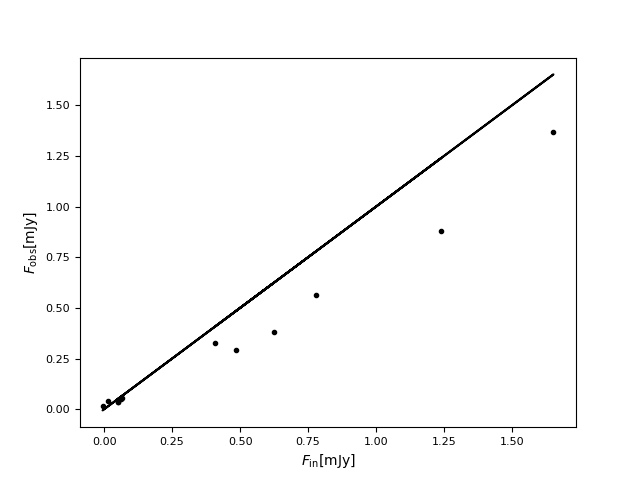

In [5]:
reducedpath3="./"
tf1p3 = ToltecSignalFits(reducedpath3, array='a2000') # To load the file
tf1p3.setWeightCut(0.6)
tf1p3.plotImage('signal_I',vmin=-0.5 , vmax=1) # shows the image
table_phot3,segm_deblend3=tf1p3.segment() # segmetation of the image
# To adjust resolution
inputmodel3=InputModelFits(filename="/Users/mariajosemejiamorales/Desktop/praticas/ngc3938_11mm_eqCalz_MJypersr_pixsize1.fits",array= "a2000",kernelFile="Kernel_LowRes_MIPS_24_to_Gauss_07.0.fits.gz")
# To adjust pixels
repromodel3=inputmodel3.reprojectInputToOutput(tf1p3)

inputmodel3.writeReproject(tf1p3)

inputmodel3.plotModObs(tf1p3,segm_deblend3,extent=(260,490,240,490)) # shows input model, out model and segmentation

tbl_input3=inputmodel3.inPhot(segm_deblend3)

inputmodel3.plotExtPhot(table_phot3) # To show the graph of comparasion fluxes 

